In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

In [3]:
student_raw_data = {
    "姓名": ["张三", "李四", "王五", "赵六", "孙七", "周八", "吴九", "郑十", None],
    "性别": ["男", "男", "女", "女", "男", "男", "女", "女", "男"],
    "语文": [88, 95, 79, 92, 85, None, 90, 83, 76],
    "数学": [92, 87, 90, 85, 78, 94, 88, 91, 82],
    "英语": [78, 90, 86, 94, 82, 75, None, 92, 88],
    "物理": [90, 85, 88, 92, 76, 95, 84, 89, 79]
}
student_df = pd.DataFrame(student_raw_data)
student_df

,姓名,性别,语文,数学,英语,物理
0,张三,男,88.0,92,78.0,90
1,李四,男,95.0,87,90.0,85
2,王五,女,79.0,90,86.0,88
3,赵六,女,92.0,85,94.0,92
4,孙七,男,85.0,78,82.0,76
5,周八,男,NaN,94,75.0,95
6,吴九,女,90.0,88,NaN,84
7,郑十,女,83.0,91,92.0,89
8,None,男,76.0,82,88.0,79


In [4]:
student_df.shape

(9, 6)

In [5]:
student_df = student_df.drop_duplicates()
student_df

,姓名,性别,语文,数学,英语,物理
0,张三,男,88.0,92,78.0,90
1,李四,男,95.0,87,90.0,85
2,王五,女,79.0,90,86.0,88
3,赵六,女,92.0,85,94.0,92
4,孙七,男,85.0,78,82.0,76
5,周八,男,NaN,94,75.0,95
6,吴九,女,90.0,88,NaN,84
7,郑十,女,83.0,91,92.0,89
8,None,男,76.0,82,88.0,79


In [6]:
student_df = student_df.dropna(subset=["姓名"])
student_df

,姓名,性别,语文,数学,英语,物理
0,张三,男,88.0,92,78.0,90
1,李四,男,95.0,87,90.0,85
2,王五,女,79.0,90,86.0,88
3,赵六,女,92.0,85,94.0,92
4,孙七,男,85.0,78,82.0,76
5,周八,男,NaN,94,75.0,95
6,吴九,女,90.0,88,NaN,84
7,郑十,女,83.0,91,92.0,89


In [7]:
subject_cols = ["语文", "数学", "英语", "物理"]
for col in subject_cols:
    col_mean = student_df[col].mean().round(0)
    student_df[col] = student_df[col].fillna(col_mean)

student_df

C:\Users\LocalHost\AppData\Local\Temp\ipykernel_12596\1886714602.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  student_df[col] = student_df[col].fillna(col_mean)


,姓名,性别,语文,数学,英语,物理
0,张三,男,88.0,92,78.0,90
1,李四,男,95.0,87,90.0,85
2,王五,女,79.0,90,86.0,88
3,赵六,女,92.0,85,94.0,92
4,孙七,男,85.0,78,82.0,76
5,周八,男,87.0,94,75.0,95
6,吴九,女,90.0,88,85.0,84
7,郑十,女,83.0,91,92.0,89


In [8]:
gender_mode = student_df["性别"].mode()
gender_mode

0    女
1    男
Name: 性别, dtype: object

In [9]:
student_df = student_df.reset_index(drop=True)
student_df

,姓名,性别,语文,数学,英语,物理
0,张三,男,88.0,92,78.0,90
1,李四,男,95.0,87,90.0,85
2,王五,女,79.0,90,86.0,88
3,赵六,女,92.0,85,94.0,92
4,孙七,男,85.0,78,82.0,76
5,周八,男,87.0,94,75.0,95
6,吴九,女,90.0,88,85.0,84
7,郑十,女,83.0,91,92.0,89


In [10]:
subject_stats = student_df[subject_cols].describe().round(2)
subject_stats

,语文,数学,英语,物理
count,8.00,8.00,8.00,8.00
mean,87.38,88.12,85.25,87.38
std,5.10,5.00,6.69,5.80
min,79.00,78.00,75.00,76.00
25%,84.50,86.50,81.00,84.75
50%,87.50,89.00,85.50,88.50
75%,90.50,91.25,90.50,90.50
max,95.00,94.00,94.00,95.00


In [11]:
avg_scores = student_df[subject_cols].mean().round(2)
avg_scores

语文    87.38
数学    88.12
英语    85.25
物理    87.38
dtype: float64

In [12]:
max_scores = student_df[subject_cols].max()
max_scores

语文    95.0
数学    94.0
英语    94.0
物理    95.0
dtype: float64

In [13]:
min_scores = student_df[subject_cols].min()
min_scores

语文    79.0
数学    78.0
英语    75.0
物理    76.0
dtype: float64

In [14]:
std_scores = student_df[subject_cols].std().round(2)
std_scores

语文    5.10
数学    5.00
英语    6.69
物理    5.80
dtype: float64

In [15]:
student_df["总分"] = student_df[subject_cols].sum(axis=1)
student_df

,姓名,性别,语文,数学,英语,物理,总分
0,张三,男,88.0,92,78.0,90,348.0
1,李四,男,95.0,87,90.0,85,357.0
2,王五,女,79.0,90,86.0,88,343.0
3,赵六,女,92.0,85,94.0,92,363.0
4,孙七,男,85.0,78,82.0,76,321.0
5,周八,男,87.0,94,75.0,95,351.0
6,吴九,女,90.0,88,85.0,84,347.0
7,郑十,女,83.0,91,92.0,89,355.0


In [16]:
student_df["个人平均分"] = student_df[subject_cols].mean(axis=1).round(2)
student_df

,姓名,性别,语文,数学,英语,物理,总分,个人平均分
0,张三,男,88.0,92,78.0,90,348.0,87.00
1,李四,男,95.0,87,90.0,85,357.0,89.25
2,王五,女,79.0,90,86.0,88,343.0,85.75
3,赵六,女,92.0,85,94.0,92,363.0,90.75
4,孙七,男,85.0,78,82.0,76,321.0,80.25
5,周八,男,87.0,94,75.0,95,351.0,87.75
6,吴九,女,90.0,88,85.0,84,347.0,86.75
7,郑十,女,83.0,91,92.0,89,355.0,88.75


In [17]:
student_df["排名"] = student_df["总分"].rank(ascending=False, method="min").astype(int)
student_df

,姓名,性别,语文,数学,英语,物理,总分,个人平均分,排名
0,张三,男,88.0,92,78.0,90,348.0,87.00,5
1,李四,男,95.0,87,90.0,85,357.0,89.25,2
2,王五,女,79.0,90,86.0,88,343.0,85.75,7
3,赵六,女,92.0,85,94.0,92,363.0,90.75,1
4,孙七,男,85.0,78,82.0,76,321.0,80.25,8
5,周八,男,87.0,94,75.0,95,351.0,87.75,4
6,吴九,女,90.0,88,85.0,84,347.0,86.75,6
7,郑十,女,83.0,91,92.0,89,355.0,88.75,3


In [18]:
student_ranked_df = student_df.sort_values(by="排名")
student_ranked_df

,姓名,性别,语文,数学,英语,物理,总分,个人平均分,排名
3,赵六,女,92.0,85,94.0,92,363.0,90.75,1
1,李四,男,95.0,87,90.0,85,357.0,89.25,2
7,郑十,女,83.0,91,92.0,89,355.0,88.75,3
5,周八,男,87.0,94,75.0,95,351.0,87.75,4
0,张三,男,88.0,92,78.0,90,348.0,87.00,5
6,吴九,女,90.0,88,85.0,84,347.0,86.75,6
2,王五,女,79.0,90,86.0,88,343.0,85.75,7
4,孙七,男,85.0,78,82.0,76,321.0,80.25,8


In [19]:
gender_subject_avg = student_df.groupby("性别")[subject_cols].mean().round(2)
gender_subject_avg

,语文,数学,英语,物理
性别,,,,
女,86.00,88.50,89.25,88.25
男,88.75,87.75,81.25,86.50


In [20]:
numeric_cols = subject_cols + ["总分", "个人平均分"]

corr_matrix = student_df[numeric_cols].corr().round(2)
corr_matrix

,语文,数学,英语,物理,总分,个人平均分
语文,1.00,-0.15,0.20,0.04,0.46,0.46
数学,-0.15,1.00,-0.29,0.81,0.55,0.55
英语,0.20,-0.29,1.00,-0.07,0.46,0.46
物理,0.04,0.81,-0.07,1.00,0.76,0.76
总分,0.46,0.55,0.46,0.76,1.00,1.00
个人平均分,0.46,0.55,0.46,0.76,1.00,1.00


In [21]:
math_corr = corr_matrix["数学"].sort_values(ascending=False)
math_corr

数学       1.00
物理       0.81
总分       0.55
个人平均分    0.55
语文      -0.15
英语      -0.29
Name: 数学, dtype: float64

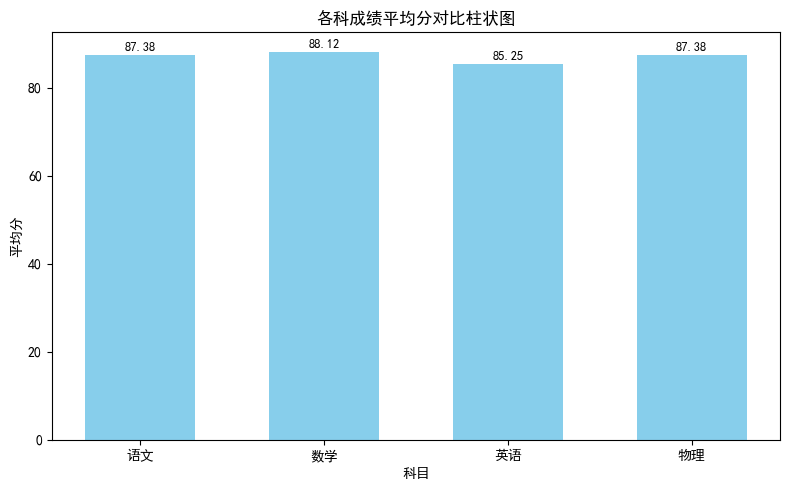

In [22]:
plt.figure(figsize=(8, 5))
x_data = avg_scores.index
y_data = avg_scores.values

plt.bar(x_data, y_data, color="skyblue", width=0.6)
plt.xlabel("科目", fontsize=10)
plt.ylabel("平均分", fontsize=10)
plt.title("各科成绩平均分对比柱状图", fontsize=12, fontweight="bold")

for i in range(len(x_data)):
    plt.text(i, y_data[i] + 0.5, str(y_data[i]), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

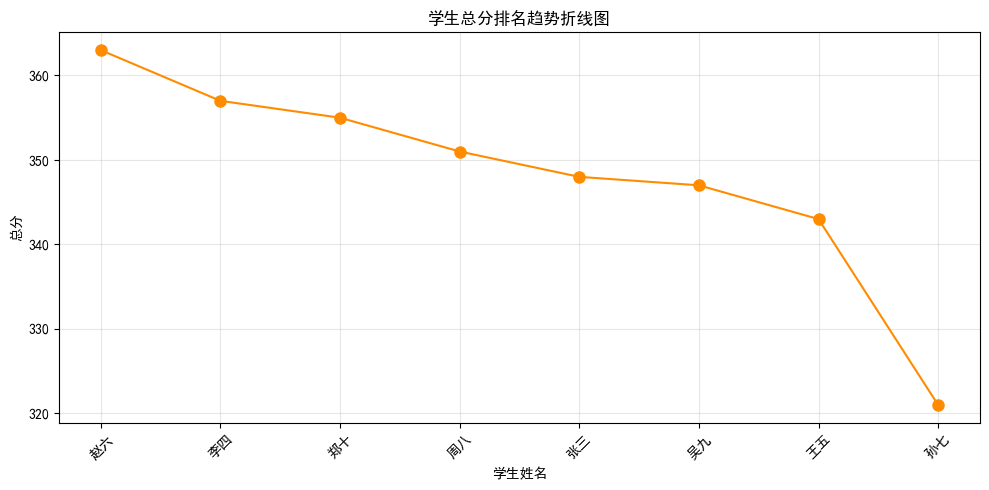

In [28]:
plt.figure(figsize=(10, 5))

x_data = student_ranked_df["姓名"]
y_data = student_ranked_df["总分"]

plt.plot(x_data, y_data, color="darkorange", linestyle="-", marker="o", markersize=8)

plt.xlabel("学生姓名", fontsize=10)
plt.ylabel("总分", fontsize=10)

plt.title("学生总分排名趋势折线图", fontsize=12, fontweight="bold")

plt.grid(alpha=0.3)

# for i in range(len(x_data)):
#     plt.text(i, y_data[i], str(y_data[i]), ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

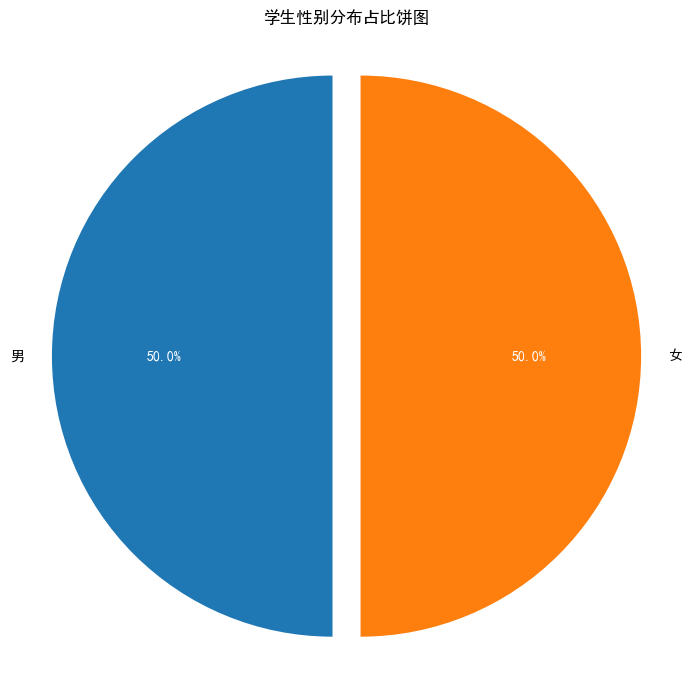

In [29]:
plt.figure(figsize=(7, 7))

gender_count = student_df["性别"].value_counts()

explode = (0.05, 0.05)
wedges, texts, autotexts = plt.pie(gender_count.values, explode=explode, labels=gender_count.index,
                                  autopct="%1.1f%%", textprops={"fontsize": 10}, startangle=90)

plt.axis("equal")

plt.title("学生性别分布占比饼图", fontsize=12, fontweight="bold")
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

plt.tight_layout()
plt.show()

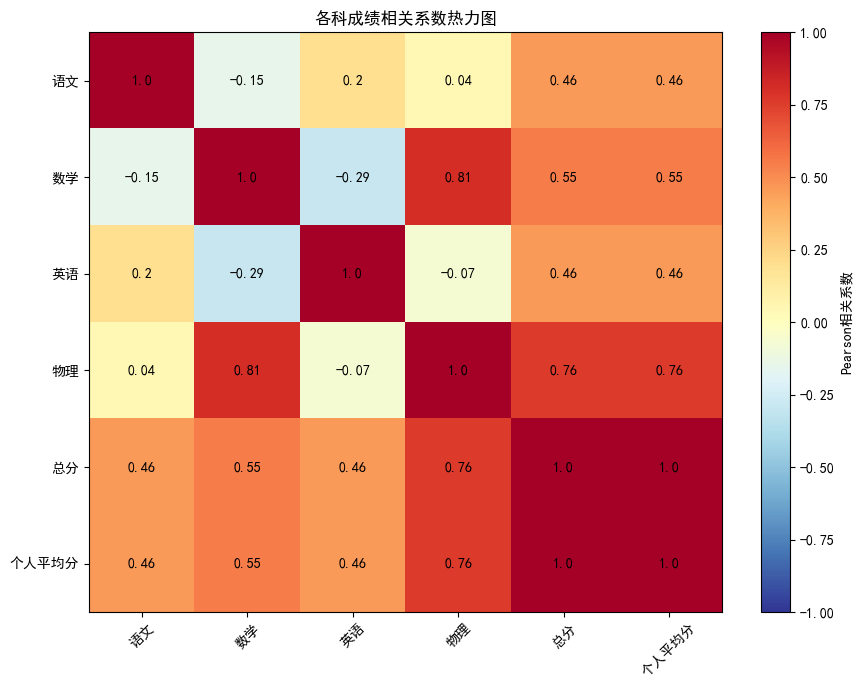

In [30]:
plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, cmap='RdYlBu_r', aspect='auto', vmin=-1, vmax=1)

plt.colorbar(label="Pearson相关系数")

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, corr_matrix.iloc[i, j], ha="center", va="center", fontsize=10)

plt.title("各科成绩相关系数热力图", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [31]:
# === 分析结论总结 ===
print("\n=== 学生成绩数据分析核心结论 ===")
print(f"1.  数据概况：本次分析共涉及{len(student_df)}名学生，包含{len(subject_cols)}门科目，数据已完成清洗（去重、填充缺失值）。")
print(f"2.  各科水平：")
for subject in avg_scores.index:
    print(f"   - {subject}平均分：{avg_scores[subject]}，最高分：{max_scores[subject]}，最低分：{min_scores[subject]}，成绩波动：{std_scores[subject]}")
top_subject = avg_scores.idxmax()
low_subject = avg_scores.idxmin()
print(f"   - 平均分最高科目：{top_subject}（{avg_scores[top_subject]}分），平均分最低科目：{low_subject}（{avg_scores[low_subject]}分）。")
print(f"3.  学生排名：")
top_student = student_ranked_df.iloc[0]["姓名"]
top_total = student_ranked_df.iloc[0]["总分"]
print(f"   - 总分第一名：{top_student}（{top_total}分）。")
print(f"4.  性别差异：")
male_avg = gender_subject_avg.loc["男", subject_cols].mean().round(2)
female_avg = gender_subject_avg.loc["女", subject_cols].mean().round(2)
print(f"   - 男生各科平均分：{male_avg}，女生各科平均分：{female_avg}。")
print(f"5.  科目相关性：")
highest_corr = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()[1]
corr_subjects = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates().index[1]
print(f"   - 相关性最强的两个科目：{corr_subjects[0]} & {corr_subjects[1]}（相关系数：{highest_corr}），呈强正相关。")


=== 学生成绩数据分析核心结论 ===
1.  数据概况：本次分析共涉及8名学生，包含4门科目，数据已完成清洗（去重、填充缺失值）。
2.  各科水平：
   - 语文平均分：87.38，最高分：95.0，最低分：79.0，成绩波动：5.1
   - 数学平均分：88.12，最高分：94.0，最低分：78.0，成绩波动：5.0
   - 英语平均分：85.25，最高分：94.0，最低分：75.0，成绩波动：6.69
   - 物理平均分：87.38，最高分：95.0，最低分：76.0，成绩波动：5.8
   - 平均分最高科目：数学（88.12分），平均分最低科目：英语（85.25分）。
3.  学生排名：
   - 总分第一名：赵六（363.0分）。
4.  性别差异：
   - 男生各科平均分：86.06，女生各科平均分：88.0。
5.  科目相关性：
   - 相关性最强的两个科目：物理 & 数学（相关系数：0.81），呈强正相关。
